In [22]:
import pandas as pd
import numpy as np
import seaborn as sns

In [23]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [24]:
df = sns.load_dataset('tips')

In [25]:
df = df[['total_bill', 'size', 'tip']]
df

,total_bill,size,tip
0,16.99,2,1.01
1,10.34,3,1.66
2,21.01,3,3.50
3,23.68,2,3.31
4,24.59,4,3.61
...,...,...,...
239,29.03,3,5.92
240,27.18,2,2.00
241,22.67,2,2.00
242,17.82,2,1.75


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   size        244 non-null    int64  
 2   tip         244 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 5.8 KB


In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score , r2_score, root_mean_squared_error

In [28]:
df['model_1'] = df['tip'].mean()
df

,total_bill,size,tip,model_1
0,16.99,2,1.01,2.998279
1,10.34,3,1.66,2.998279
2,21.01,3,3.50,2.998279
3,23.68,2,3.31,2.998279
4,24.59,4,3.61,2.998279
...,...,...,...,...
239,29.03,3,5.92,2.998279
240,27.18,2,2.00,2.998279
241,22.67,2,2.00,2.998279
242,17.82,2,1.75,2.998279


In [29]:
df['resid_1'] = df['tip'] - df['model_1']
df

,total_bill,size,tip,model_1,resid_1
0,16.99,2,1.01,2.998279,-1.988279
1,10.34,3,1.66,2.998279,-1.338279
2,21.01,3,3.50,2.998279,0.501721
3,23.68,2,3.31,2.998279,0.311721
4,24.59,4,3.61,2.998279,0.611721
...,...,...,...,...,...
239,29.03,3,5.92,2.998279,2.921721
240,27.18,2,2.00,2.998279,-0.998279
241,22.67,2,2.00,2.998279,-0.998279
242,17.82,2,1.75,2.998279,-1.248279


In [30]:
model = DecisionTreeRegressor(max_leaf_nodes=8)

In [31]:
model.fit(df[['total_bill', 'size']], df['resid_1'])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [32]:
df['model_2'] = model.predict(df[['total_bill', 'size']])
df

,total_bill,size,tip,model_1,resid_1,model_2
0,16.99,2,1.01,2.998279,-1.988279,-0.046242
1,10.34,3,1.66,2.998279,-1.338279,-1.048858
2,21.01,3,3.50,2.998279,0.501721,0.506819
3,23.68,2,3.31,2.998279,0.311721,0.506819
4,24.59,4,3.61,2.998279,0.611721,0.921721
...,...,...,...,...,...,...
239,29.03,3,5.92,2.998279,2.921721,0.506819
240,27.18,2,2.00,2.998279,-0.998279,0.506819
241,22.67,2,2.00,2.998279,-0.998279,0.506819
242,17.82,2,1.75,2.998279,-1.248279,-0.046242


[Text(0.4230769230769231, 0.9, 'x[0] <= 20.47\nsquared_error = 1.907\nsamples = 244\nvalue = 0.0'),
 Text(0.15384615384615385, 0.7, 'x[0] <= 13.875\nsquared_error = 0.674\nsamples = 153\nvalue = -0.597'),
 Text(0.28846153846153844, 0.8, 'True  '),
 Text(0.07692307692307693, 0.5, 'squared_error = 0.469\nsamples = 69\nvalue = -1.049'),
 Text(0.23076923076923078, 0.5, 'x[0] <= 16.28\nsquared_error = 0.537\nsamples = 84\nvalue = -0.226'),
 Text(0.15384615384615385, 0.3, 'squared_error = 0.349\nsamples = 30\nvalue = -0.55'),
 Text(0.3076923076923077, 0.3, 'squared_error = 0.551\nsamples = 54\nvalue = -0.046'),
 Text(0.6923076923076923, 0.7, 'x[0] <= 48.22\nsquared_error = 2.372\nsamples = 91\nvalue = 1.004'),
 Text(0.5576923076923077, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[1] <= 3.5\nsquared_error = 1.651\nsamples = 88\nvalue = 0.848'),
 Text(0.46153846153846156, 0.3, 'squared_error = 1.317\nsamples = 51\nvalue = 0.507'),
 Text(0.6153846153846154, 0.3, 'x[0] <= 31.085\nsquared_e

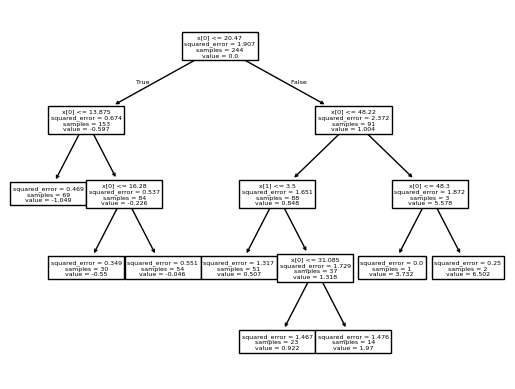

In [33]:
from sklearn.tree import plot_tree
plot_tree(model)

In [34]:
lr = 0.1
df['pred_2'] = df.model_1+(lr* df.model_2)
df

,total_bill,size,tip,model_1,resid_1,model_2,pred_2
0,16.99,2,1.01,2.998279,-1.988279,-0.046242,2.993655
1,10.34,3,1.66,2.998279,-1.338279,-1.048858,2.893393
2,21.01,3,3.50,2.998279,0.501721,0.506819,3.048961
3,23.68,2,3.31,2.998279,0.311721,0.506819,3.048961
4,24.59,4,3.61,2.998279,0.611721,0.921721,3.090451
...,...,...,...,...,...,...,...
239,29.03,3,5.92,2.998279,2.921721,0.506819,3.048961
240,27.18,2,2.00,2.998279,-0.998279,0.506819,3.048961
241,22.67,2,2.00,2.998279,-0.998279,0.506819,3.048961
242,17.82,2,1.75,2.998279,-1.248279,-0.046242,2.993655


In [35]:
df['resid_2'] = df.tip - df.pred_2
df

,total_bill,size,tip,model_1,resid_1,model_2,pred_2,resid_2
0,16.99,2,1.01,2.998279,-1.988279,-0.046242,2.993655,-1.983655
1,10.34,3,1.66,2.998279,-1.338279,-1.048858,2.893393,-1.233393
2,21.01,3,3.50,2.998279,0.501721,0.506819,3.048961,0.451039
3,23.68,2,3.31,2.998279,0.311721,0.506819,3.048961,0.261039
4,24.59,4,3.61,2.998279,0.611721,0.921721,3.090451,0.519549
...,...,...,...,...,...,...,...,...
239,29.03,3,5.92,2.998279,2.921721,0.506819,3.048961,2.871039
240,27.18,2,2.00,2.998279,-0.998279,0.506819,3.048961,-1.048961
241,22.67,2,2.00,2.998279,-0.998279,0.506819,3.048961,-1.048961
242,17.82,2,1.75,2.998279,-1.248279,-0.046242,2.993655,-1.243655


In [36]:
# model 3 
# input -> total_bill, size    dependent-> resid_2
model3 = DecisionTreeRegressor(max_leaf_nodes=8)
model3.fit(df[['total_bill', 'size']], df.resid_2)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [37]:
df['model_3'] = model3.predict(df[['total_bill', 'size']])
df

,total_bill,size,tip,model_1,resid_1,model_2,pred_2,resid_2,model_3
0,16.99,2,1.01,2.998279,-1.988279,-0.046242,2.993655,-1.983655,-0.041617
1,10.34,3,1.66,2.998279,-1.338279,-1.048858,2.893393,-1.233393,-1.010807
2,21.01,3,3.50,2.998279,0.501721,0.506819,3.048961,0.451039,0.456137
3,23.68,2,3.31,2.998279,0.311721,0.506819,3.048961,0.261039,0.456137
4,24.59,4,3.61,2.998279,0.611721,0.921721,3.090451,0.519549,0.849347
...,...,...,...,...,...,...,...,...,...
239,29.03,3,5.92,2.998279,2.921721,0.506819,3.048961,2.871039,0.456137
240,27.18,2,2.00,2.998279,-0.998279,0.506819,3.048961,-1.048961,0.456137
241,22.67,2,2.00,2.998279,-0.998279,0.506819,3.048961,-1.048961,0.456137
242,17.82,2,1.75,2.998279,-1.248279,-0.046242,2.993655,-1.243655,-0.041617


In [38]:
df['pred_3'] = df.pred_2+df.model_3
df

,total_bill,size,tip,model_1,resid_1,model_2,pred_2,resid_2,model_3,pred_3
0,16.99,2,1.01,2.998279,-1.988279,-0.046242,2.993655,-1.983655,-0.041617,2.952037
1,10.34,3,1.66,2.998279,-1.338279,-1.048858,2.893393,-1.233393,-1.010807,1.882586
2,21.01,3,3.50,2.998279,0.501721,0.506819,3.048961,0.451039,0.456137,3.505098
3,23.68,2,3.31,2.998279,0.311721,0.506819,3.048961,0.261039,0.456137,3.505098
4,24.59,4,3.61,2.998279,0.611721,0.921721,3.090451,0.519549,0.849347,3.939798
...,...,...,...,...,...,...,...,...,...,...
239,29.03,3,5.92,2.998279,2.921721,0.506819,3.048961,2.871039,0.456137,3.505098
240,27.18,2,2.00,2.998279,-0.998279,0.506819,3.048961,-1.048961,0.456137,3.505098
241,22.67,2,2.00,2.998279,-0.998279,0.506819,3.048961,-1.048961,0.456137,3.505098
242,17.82,2,1.75,2.998279,-1.248279,-0.046242,2.993655,-1.243655,-0.041617,2.952037


In [45]:
# df[['tip', 'pred_3']].values
r2_score(df.tip, df.pred_3)

0.5852387519041211

In [48]:
adjusted_rand_score(df.tip, df.pred_3)

/home/lalithrajr/Machine_learning_Practice/venv/lib/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


0.022183887215543274

In [50]:
root_mean_squared_error(df.tip, df.pred_3)

0.88926223706696

In [ ]:
class GradientBoost:
    def __init__(self, n_model, lr):
        self.n_model = n_model
        self.lr = lr
        for i in range(1,self.n_model)+1:
            def main_func(self, X, Y):
                if i == 1:
                    X[f'{i}'] = np.mean(Y)
                    X[f"res_{i}"] = Y - X[i]
                else:
                    